<div align="center">

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/apriori3d/ico/blob/main/src/examples/ml/cv/cifar/ico_cifar_complete_flow.ipynb)

**CIFAR-10 Classification with ICO Framework**

</div>

---


This notebook demonstrates a complete machine learning pipeline for CIFAR-10 image classification using a functional approach with the Apriori ICO framework.

**🚀 The pipeline completely replaces PyTorch DataLoader**, making training logic fully transparent and composable through functional operators. Instead of black-box data loading, you get explicit, type-safe, and debuggable data transformations.

**Note:** For demonstration purposes, this example does not use multiprocessing agents as PyTorch DataLoader worker replacements (see example TBD).

## 📚 Table of Contents

### Data Pipeline (Replaces PyTorch DataLoader)
1. **[Data Structures and Dataset Loading](#1-data-structures-and-dataset-loading)** - CifarItem, CifarDataset
2. **[Creating Training Data Source](#2-creating-training-data-source)** - IcoSource, data splitting
3. **[Data Processing Pipeline Composition](#3-data-processing-pipeline-composition)** - functional composition, batching
4. **[Pipeline Testing and Visualization](#4-pipeline-testing-and-data-visualization)** - functionality verification
5. **[Data Augmentation System](#5-data-augmentation-system)** - image transformations
6. **[Alternative Composition via IcoPipeline](#6-alternative-composition-via-icopipeline)** - declarative approach
7. **[Data Collation into Batches](#7-data-collation-into-batches)** - CifarBatch, grouping
8. **[Full Training Pipeline Integration](#8-full-training-pipeline-integration)** - component integration
9. **[Full Pipeline Testing with Augmentation](#9-full-pipeline-testing-with-augmentation)** - augmentation validation

### Model and Training
10. **[ResNet-18 Neural Network Setup for CIFAR-10](#10-resnet-18-neural-network-setup-for-cifar-10)** - CIFAR-10 adaptation
11. **[Training System](#11-contextual-training-operations-system)** - CifarContext, train_step
12. **[Training Process Organization](#12-training-process-organization)** - IcoEpoch, train_flow
13. **[First Training Run](#13-first-training-execution)** - initialization and testing

### Validation and Evaluation
14. **[Validation Pipeline Creation](#14-validation-pipeline-creation)** - quality assessment
15. **[Model Validation System](#15-model-validation-system)** - CifarEvalContext, metrics
16. **[Complete Validation Flow](#16-complete-validation-flow)** - end-to-end validation

### Full Training Loop
17. **[Training and Validation Integration](#17-training-and-validation-integration)** - epoch_flow
18. **[Full Epoch Execution](#18-full-epoch-execution)** - train+validation test
19. **[Multi-Epoch Process](#19-multi-epoch-training-process-creation)** - IcoProcess
20. **[Final Training](#20-final-complete-training-execution)** - full 5-epoch cycle

**[Conclusion: ICO Framework Advantages](#conclusion-ico-framework-advantages)** - framework benefits vs PyTorch DataLoader  
**[Next Steps](#next-steps)** - improvement ideas

---

### Install dependencies if running in Google Colab

In [1]:

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🚀 Running in Google Colab - installing dependencies...")

    # Install PyTorch and dependencies
    %pip install -q torch torchvision matplotlib

    # Install Apriori ICO framework from GitHub (next branch)
    %pip install --upgrade -q git+https://github.com/apriori3d/ico.git

    print("✅ Dependencies installed successfully!")
else:
    print("⚠️ Running locally - please run 'poetry install -E vision' to install dependencies")

⚠️ Running locally - please run 'poetry install -E vision' to install dependencies


---

## Global parameters

In [2]:
train_split_ratio = 0.002  # make it 0.2% of a real dataset size for speed up in demo.
val_split_ratio = 0.001

## 1. Data Structures and Dataset Loading

In this section, we define the basic data structures for working with CIFAR-10:

``CifarItem``
A dataclass representing one data element:
- **image**: Tensor of size (3, 32, 32) - RGB image 32×32 pixels
- **label**: Tensor of size (,) - scalar class label (0-9)

``CifarDataset``
Wrapper class over torchvision.CIFAR10 with memory preloading.


In [3]:
from collections.abc import Iterator
from dataclasses import dataclass

import torch
from torch import Tensor
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor


@dataclass(slots=True, frozen=True)
class CifarItem:
    image: Tensor  # (3, 32, 32)
    label: Tensor  # (,)


class CifarDataset:
    images: Tensor  # (N, 3, 32, 32)
    labels: Tensor  # (N,)

    def __init__(self, root: str = "data/"):
        dataset = CIFAR10(root=root, download=True, transform=ToTensor())

        # Preload all data into memory as tensors
        self.images = torch.stack(
            [dataset[i][0] for i in range(len(dataset))]
        )  # (N, 3, 32, 32)
        self.labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])  # (N,)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> CifarItem:
        return CifarItem(image=self.images[index], label=self.labels[index])

    def __iter__(self) -> Iterator[CifarItem]:
        for i in range(len(self)):
            yield self[i]

## 2. Creating Training Data Source

Here we create **`IcoSource[int]`** - a functional data source:

``IcoSource[int]`` characteristics:
- **Lazy execution**: lambda returns indices only when called
- **Typing**: specify stream element types (`int`)
- **Note**: all the data in any flow originated from a source, this is why it take `None` as input and has signature () -> `Iterator[Int]` 

``.describe()`` method:
Outputs pipeline structure - useful for:
- Debugging data flow architecture
- Documenting complex pipelines
- Visualizing dependencies between operators



In [4]:
import random

from ico import IcoSource

dataset = CifarDataset()
dataset_size = len(dataset)
all_indices = list(range(dataset_size))
random.shuffle(all_indices)

train_split = int(dataset_size * train_split_ratio)
train_source = IcoSource[int](
    lambda: all_indices[
        :train_split
    ],  # we use a lambda or a function to provide the data on demand
    name="CIFAR10 train indices",
)

# `describe()` shows a flow plan as a list of operator(top to bottom), with a signature and a name
train_source.describe()

──────────────────────────────────────── Flow plan: CIFAR10 train indices ─────────────────────────────────────────

 Flow                             Signature           Name                  
 📚IcoSource(<lambda>, size=100)  () → Iterator[int]  CIFAR10 train indices

## 3. Data Processing Pipeline Composition

Demonstration of **functional composition** of operators through the `|` (pipe) operator:

``shuffle_indices(indices: Iterator[int]) -> Iterator[int]``
- **Purpose**: Suffle indices before each iteration

``fetch_item(index: int) -> CifarItem``
- **Purpose**: extract dataset element by index
- **Pattern**: Index → Data transformation
- **Connection**: uses global `dataset` object

Pipeline composition:
Index Source → Shuffling → Item Loading → Batching


Key concepts:
- **`.stream()`**: converts single operator to streaming (works with Iterator)
- **IcoBatcher**: groups elements into fixed-size batches

This pattern allows easy modification and extension of the pipeline.

In [5]:
from collections.abc import Iterator

from ico import IcoBatcher, IcoOperator, operator


@operator()
def shuffle_indices(indices: Iterator[int]) -> Iterator[int]:
    indices_list = list(indices)
    random.shuffle(indices_list)
    yield from indices_list


@operator()
def fetch_item(index: int) -> CifarItem:
    return dataset[index]


# We need explicitly specify the type of the batcher,
# because Python's type inference cannot infer the type of the items here.
batch_size = 8
batcher = IcoBatcher[CifarItem](batch_size=batch_size)

# The types of operators for shuffling and fetching items are inferred from the function signatures.
train_data_flow = train_source | shuffle_indices | fetch_item.stream() | batcher
train_data_flow.name = "Train Input Flow"
train_data_flow.describe()

─────────────────────────────────────────── Flow plan: Train Input Flow ───────────────────────────────────────────

 Flow                             Signature                                            Name                  
 📚IcoSource(<lambda>, size=100)  () → Iterator[int]                                   CIFAR10 train indices 
 shuffle_indices                  Iterator[int] → Iterator[int]                                              
 ╭── for each in 🎞️ IcoStream()    Iterator[int] → Iterator[CifarItem]                                        
 │   fetch_item                   int → CifarItem                                                            
 ╰─▸ yield                        Iterator[CifarItem]                                                        
 📦IcoBatcher(batch_size=8)       Iterator[CifarItem] → Iterator[Iterator[CifarItem]]  batcher(8)           

## 4. Pipeline Testing and Data Visualization

Verification of the created pipeline's functionality



Number of items in batch: 8


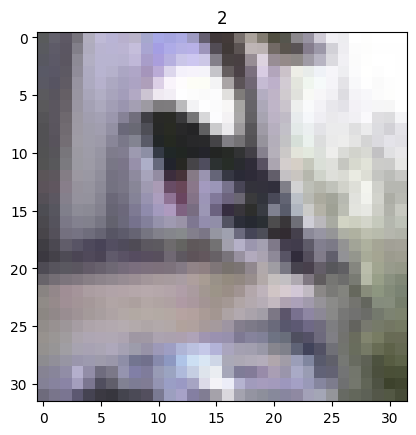

In [6]:
from matplotlib import pyplot as plt

# The first element in the flow is a source, so the input should be None, source will generate the data on demand.
for item_batch in train_data_flow(None):
    items = list(item_batch)
    print(f"Number of items in batch: {len(items)}")

    item = items[0]
    image = item.image.detach().cpu().numpy().transpose(1, 2, 0)
    label = item.label.item()

    plt.plot()
    plt.title(label)
    plt.imshow(image)

    break

## 5. Data Augmentation System

**Flexible augmentation system** using callable objects that integrate seamlessly with ICO operators:

``CifarTransform`` characteristics:
- **Stochastic transformations**: probabilistic application via `p` parameter 

- **Functional composition**: each transform is a callable that can be wrapped in `IcoOperator`- **Type safety**: maintains CifarItem -> CifarItem signature throughout pipeline

In [7]:
from abc import ABC, abstractmethod

from torchvision.transforms import functional as F


class CifarTransform(ABC):
    p: float
    factor: float

    def __init__(self, p: float = 1.0, factor: float = 1.0):
        self.p = p
        self.factor = factor

    @abstractmethod
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        raise NotImplementedError

    def __call__(self, item: CifarItem) -> CifarItem:
        if torch.rand(1) >= self.p:
            return item

        return CifarItem(
            image=self._image_transform(item.image, self.factor), label=item.label
        )


class HorizontalFlip(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.hflip(image)


class VerticalFlip(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.vflip(image)


class AdjustBrightness(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.adjust_brightness(image, factor)


class AdjustContrast(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.adjust_contrast(image, factor)


item_aug_flow = (
    IcoOperator(HorizontalFlip())
    | IcoOperator(VerticalFlip())
    | IcoOperator(AdjustBrightness(factor=0.2))
    | IcoOperator(AdjustContrast(factor=0.2))
)
item_aug_flow.name = "Item augmentation flow"
item_aug_flow.describe()

──────────────────────────────────────── Flow plan: Item augmentation flow ────────────────────────────────────────

 Flow                Signature              Name 
 HorizontalFlip()    CifarItem → CifarItem       
 VerticalFlip()      CifarItem → CifarItem       
 AdjustBrightness()  CifarItem → CifarItem       
 AdjustContrast()    CifarItem → CifarItem      

## 6. Alternative Composition via IcoPipeline

**Declarative pipeline construction** - alternative to `|` operator:

``IcoPipeline`` advantages:
- **Auto-wrapping**: takes callable objects directly, no manual `IcoOperator()` wrapping
- **Named pipelines**: built-in naming for better debugging
- **Same functionality**: equivalent to `|` operator composition but more concise

In [8]:
from ico import IcoPipeline

item_aug_flow = IcoPipeline(
    HorizontalFlip(),
    VerticalFlip(),
    AdjustBrightness(),
    AdjustContrast(),
    name="Item augmentation flow",
)
item_aug_flow.describe()

──────────────────────────────────────── Flow plan: Item augmentation flow ────────────────────────────────────────

 Flow                Signature              Name 
 HorizontalFlip()    CifarItem → CifarItem       
 VerticalFlip()      CifarItem → CifarItem       
 AdjustBrightness()  CifarItem → CifarItem       
 AdjustContrast()    CifarItem → CifarItem      

## 7. Data Collation into Batches

**Custom batch creation** replacing PyTorch's default collate:

``CifarBatch`` features:

- **Type-safe batching**: `Iterator[CifarItem]` -> `CifarBatch` transformation  
- **Memory optimized**: `@final` class with `__slots__` for performance

In [9]:
from typing import final


@final
class CifarBatch:
    __slots__ = ("images", "labels")

    images: Tensor  # (B, 3, 32, 32)
    labels: Tensor  # (B,)

    def __init__(self, items: Iterator[CifarItem]):
        items_list = list(items)
        self.images = torch.stack([item.image for item in items_list])  # (B, 3, 32, 32)
        self.labels = torch.tensor([item.label for item in items_list])  # (B,)


def collate(items: Iterator[CifarItem]) -> CifarBatch:
    return CifarBatch(items)


aug_flow = item_aug_flow.stream() | IcoOperator(collate)
aug_flow.name = "Full Augmentation flow"
aug_flow.describe()

──────────────────────────────────────── Flow plan: Full Augmentation flow ────────────────────────────────────────

 Flow                           Signature                                  Name 
 ╭── for each in 🎞️ IcoStream()  Iterator[CifarItem] → Iterator[CifarItem]       
 │   HorizontalFlip()           CifarItem → CifarItem                           
 │   VerticalFlip()             CifarItem → CifarItem                           
 │   AdjustBrightness()         CifarItem → CifarItem                           
 │   AdjustContrast()           CifarItem → CifarItem                           
 ╰─▸ yield                      Iterator[CifarItem]                             
 collate                        Iterator[CifarItem] → CifarBatch               

## 8. Full Training Pipeline Integration

**Complete DataLoader replacement** - composing all components:

Pipeline composition benefits:
- **Pipeline composition**: `train_data_flow | aug_flow` creating end-to-end flow
- **Auto-naming**: framework automatically tracks pipeline composition
- **Ready for training**: replaces PyTorch DataLoader completely

In [10]:
full_train_data_flow = train_data_flow | aug_flow.stream()
full_train_data_flow.name = "Full Train Data Flow with Augmentation"
full_train_data_flow.describe()

──────────────────────────────── Flow plan: Full Train Data Flow with Augmentation ────────────────────────────────

 Flow                               Signature                                             Name                  
 📚IcoSource(<lambda>, size=100)    () → Iterator[int]                                    CIFAR10 train indices 
 shuffle_indices                    Iterator[int] → Iterator[int]                                               
 ╭── for each in 🎞️ IcoStream()      Iterator[int] → Iterator[CifarItem]                                         
 │   fetch_item                     int → CifarItem                                                             
 ╰─▸ yield                          Iterator[CifarItem]                                                         
 📦IcoBatcher(batch_size=8)         Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)            
 ╭── for each in 🎞️ IcoStream()      Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                        
 │   ╭── for each in 🎞️ IcoStream()  Iterator[CifarItem] → Iterator[CifarItem]                                   
 │   │   HorizontalFlip()           CifarItem → CifarItem                                                       
 │   │   VerticalFlip()             CifarItem → CifarItem                                                       
 │   │   AdjustBrightness()         CifarItem → CifarItem                                                       
 │   │   AdjustContrast()           CifarItem → CifarItem                                                       
 │   ╰─▸ yield                      Iterator[CifarItem]                                                         
 │   collate                        Iterator[CifarItem] → CifarBatch                                            
 ╰─▸ yield                          Iterator[CifarBatch]

## 9. Full Pipeline Testing with Augmentation

**Pipeline validation** - ensuring everything works together:

Validation checks:
- **Dimension verification**: batch shapes match model expectations
- **Visual inspection**: augmentations preserve semantic meaning
- **Type safety**: `CifarBatch` objects created correctly

Batch images shape: torch.Size([8, 3, 32, 32]), Batch labels shape: torch.Size([8])


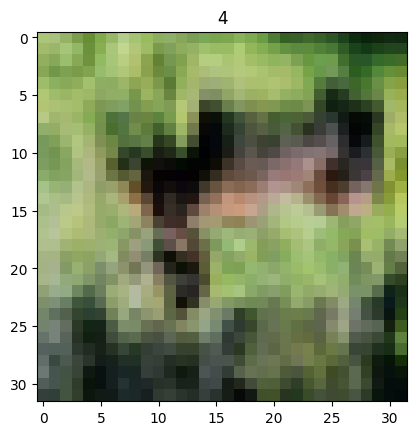

In [11]:
for batch in full_train_data_flow(None):
    print(
        f"Batch images shape: {batch.images.shape}, Batch labels shape: {batch.labels.shape}"
    )

    image = batch.images[0].detach().cpu().numpy().transpose(1, 2, 0)
    label = batch.labels[0].item()

    plt.plot()
    plt.title(label)
    plt.imshow(image)
    break

## 10. ResNet-18 Neural Network Setup for CIFAR-10

**Model adaptation for CIFAR-10** - modifying standard ResNet-18:

ResNet-18 modifications for CIFAR-10:
- **Smaller initial conv**: kernel_size=3, stride=1 instead of 7, 2 for 32×32 images
- **Remove MaxPool**: `nn.Identity()` to preserve spatial dimensions  
- **CIFAR-10 classifier**: 10 output classes instead of ImageNet's 1000

In [12]:
import torch.nn as nn
from torchvision.models import resnet18


def create_cifar10_resnet18(num_classes: int = 10):
    model = resnet18()
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, num_classes)
    return model


model = create_cifar10_resnet18()
outputs = model(batch.images)
print(f"Outputs shape: {outputs.shape}")

Outputs shape: torch.Size([8, 10])


## 11. Contextual Training Operations System

**Stateful training with Context pattern** - managing training state functionally:

- ``CifarContext``:
Dataclass holding model, optimizer, loss function, and training state

- ``train_step``: Declarative way to compose pipeline, like `IcoPipeline`, but first operator has signature: Input, Context -> Output

- Applies `CifarBatch` to `CifarContext` and produces updated `CifarContext```IcoContextPipeline``

- Context functions: ``save_checkpoint_step``: takes and returns context with checkpointing

- ``logging_step``: takes and returns context with logging

In [13]:
from dataclasses import dataclass

from ico import IcoContextPipeline


@dataclass(slots=True)
class CifarContext:
    model: nn.Module
    optimizer: torch.optim.Optimizer
    loss_fn: torch.nn.Module = torch.nn.CrossEntropyLoss()
    iter_num: int = 0
    total_loss: float = 0.0


def train_step(batch: CifarBatch, context: CifarContext) -> CifarContext:
    context.optimizer.zero_grad()

    outputs = context.model(batch.images)
    loss = context.loss_fn(outputs, batch.labels)
    loss.backward()
    context.optimizer.step()

    context.total_loss = loss.item()
    context.iter_num += 1
    return context


def logging_step(context: CifarContext) -> CifarContext:
    if context.iter_num % 10 == 0:
        print(f"Iteration {context.iter_num}, Loss: {context.total_loss:.4f}")
    return context


def save_checkpoint_step(context: CifarContext) -> CifarContext:
    if context.iter_num % 100 == 0:
        print(f"Checkpointing model at iteration {context.iter_num}")
    return context


train_pipeline = IcoContextPipeline(train_step, logging_step, save_checkpoint_step)
train_pipeline.name = "Training Pipeline"
train_pipeline.describe()

────────────────────────────────────────── Flow plan: Training Pipeline ───────────────────────────────────────────

 Flow                  Signature                                Name 
 train_step            CifarBatch, CifarContext → CifarContext       
 logging_step          CifarContext → CifarContext                   
 save_checkpoint_step  CifarContext → CifarContext                  

## 12. Training Process Organization

**High-level training abstractions** with ICO concepts:

- ``IcoEpoch``:
Processes entire data source through context operations

- `start_train()` sets model to training mode

In [14]:
from ico import IcoEpoch


def start_train(context: CifarContext) -> CifarContext:
    context.model.train()
    return context


train_epoch = IcoEpoch(
    source=full_train_data_flow,
    context_operator=train_pipeline,
)
train_epoch.name = "Training Epoch"

train_flow = IcoOperator(start_train) | train_epoch
train_flow.name = "Train Flow"
train_flow.describe()

────────────────────────────────────────────── Flow plan: Train Flow ──────────────────────────────────────────────

 Flow                                   Signature                                             Name                 
 start_train                            CifarContext → CifarContext                                                
 🧠IcoEpoch()                           Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch       
 ╭── for each in                        Iterator[CifarBatch]                                                       
 │   📚IcoSource(<lambda>, size=100)    () → Iterator[int]                                    CIFAR10 train indic… 
 │   shuffle_indices                    Iterator[int] → Iterator[int]                                              
 │   ╭── for each in 🎞️ IcoStream()      Iterator[int] → Iterator[CifarItem]                                        
 │   │   fetch_item                     int → CifarItem                                                            
 │   ╰─▸ yield                          Iterator[CifarItem]                                                        
 │   📦IcoBatcher(batch_size=8)         Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)           
 │   ╭── for each in 🎞️ IcoStream()      Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                       
 │   │   ╭── for each in 🎞️ IcoStream()  Iterator[CifarItem] → Iterator[CifarItem]                                  
 │   │   │   HorizontalFlip()           CifarItem → CifarItem                                                      
 │   │   │   VerticalFlip()             CifarItem → CifarItem                                                      
 │   │   │   AdjustBrightness()         CifarItem → CifarItem                                                      
 │   │   │   AdjustContrast()           CifarItem → CifarItem                                                      
 │   │   ╰─▸ yield                      Iterator[CifarItem]                                                        
 │   │   collate                        Iterator[CifarItem] → CifarBatch                                           
 │   ╰─▸ yield                          Iterator[CifarBatch]                                                       
 ├─▸ apply                              CifarBatch, CifarContext                                                   
 │   train_step                         CifarBatch, CifarContext → CifarContext                                    
 │   logging_step                       CifarContext → CifarContext                                                
 │   save_checkpoint_step               CifarContext → CifarContext                                                
 ╰─▸ emit                               CifarContext

## 13. First Training Execution

**Running the first training epoch** - testing the complete system:

- Context initialization: Create `CifarContext` with model, optimizer, loss function

- `train_flow(context)` returns updated context with trained weights

In [15]:
model = create_cifar10_resnet18()

context = CifarContext(
    model=model,
    optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
    loss_fn=torch.nn.CrossEntropyLoss(),
)


context_epoch1 = train_flow(context)

Iteration 10, Loss: 5.7927


## 14. Validation Pipeline Creation

**Validation data pipeline** - simpler than training pipeline:

Validation characteristics:
- **No shuffling**: deterministic evaluation order
- **No batching**: element-wise processing for precise metrics  
- **No augmentation**: evaluate on original unmodified data
- **Stream processing**: `IcoOperator(fetch_item).stream()` for individual item evaluation

In [16]:
val_split = int(dataset_size * val_split_ratio)
val_source = IcoSource[int](
    lambda: all_indices[-val_split:], name="CIFAR10 evaluation indices"
)


val_data_flow = val_source | IcoOperator(fetch_item).stream()
val_data_flow.name = "Validation Flow"
val_data_flow.describe()

─────────────────────────────────────────── Flow plan: Validation Flow ────────────────────────────────────────────

 Flow                            Signature                            Name                       
 📚IcoSource(<lambda>, size=50)  () → Iterator[int]                   CIFAR10 evaluation indices 
 ╭── for each in 🎞️ IcoStream()   Iterator[int] → Iterator[CifarItem]                             
 │   IcoOperator()               int → CifarItem                                                 
 ╰─▸ yield                       Iterator[CifarItem]

## 15. Model Validation System

**Accuracy calculation with context pattern**:

- ``CifarEvalContext`` Holds validation state (accuracy counters + reference to trained model)
- ``calculate_accuracy()`` Processes individual CifarItems and update EvalContext

In [17]:
from dataclasses import dataclass

from ico import IcoContextOperator


@dataclass(slots=True)
class CifarEvalContext:
    train_context: CifarContext
    accuracy: float = 0.0
    total_samples: int = 0


def calculate_accuracy(item: CifarItem, context: CifarEvalContext) -> CifarEvalContext:
    with torch.no_grad():
        outputs = context.train_context.model(item.image.unsqueeze(0))  # (1, 10)

        predicted = torch.argmax(outputs, dim=1)
        correct = predicted.item() == item.label
        context.total_samples += 1
        context.accuracy += int(correct)

    return context


val_epoch = IcoEpoch(
    source=val_data_flow,
    context_operator=IcoContextOperator(calculate_accuracy),
    name="Validation Epoch",
)
val_epoch.describe()

─────────────────────────────────────────── Flow plan: Validation Epoch ───────────────────────────────────────────

 Flow                              Signature                                               Name                    
 🧠IcoEpoch()                      Iterator[CifarItem], CifarEvalContext → CifarEvalCont…  Validation Epoch        
 ╭── for each in                   Iterator[CifarItem]                                                             
 │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                      CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                             
 │   │   IcoOperator()             int → CifarItem                                                                 
 │   ╰─▸ yield                     Iterator[CifarItem]                                                             
 ├─▸ apply                         CifarItem, CifarEvalContext                                                     
 │   calculate_accuracy            CifarItem, CifarEvalContext → CifarEvalContext                                  
 ╰─▸ emit                          CifarEvalContext

## 16. Complete Validation Flow

**End-to-end validation pipeline** with context transformations:

Context transitions - evaluation state isolated and then returned to training context:

`CifarContext` → `CifarEvalContext` → `CifarContext`

Functional composition: 

`start_eval | val_epoch | log_accuracy | end_eval`

In [18]:
def start_eval(context: CifarContext) -> CifarEvalContext:
    context.model.eval()
    return CifarEvalContext(train_context=context)


def log_accuracy(context: CifarEvalContext) -> CifarEvalContext:
    accuracy = (
        context.accuracy / context.total_samples if context.total_samples > 0 else 0.0
    )
    print(
        f"Validation Accuracy: {accuracy * 100:.2f}% ({context.accuracy}/{context.total_samples})"
    )
    return context


def end_eval(context: CifarEvalContext) -> CifarContext:
    return context.train_context


val_flow = (
    IcoOperator(start_eval)
    | val_epoch
    | IcoOperator(log_accuracy)
    | IcoOperator(end_eval)
)
val_flow.name = "Validation Flow"
val_flow.describe()

─────────────────────────────────────────── Flow plan: Validation Flow ────────────────────────────────────────────

 Flow                              Signature                                               Name                    
 start_eval                        CifarContext → CifarEvalContext                                                 
 🧠IcoEpoch()                      Iterator[CifarItem], CifarEvalContext → CifarEvalCont…  Validation Epoch        
 ╭── for each in                   Iterator[CifarItem]                                                             
 │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                      CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                             
 │   │   IcoOperator()             int → CifarItem                                                                 
 │   ╰─▸ yield                     Iterator[CifarItem]                                                             
 ├─▸ apply                         CifarItem, CifarEvalContext                                                     
 │   calculate_accuracy            CifarItem, CifarEvalContext → CifarEvalContext                                  
 ╰─▸ emit                          CifarEvalContext                                                                
 log_accuracy                      CifarEvalContext → CifarEvalContext                                             
 end_eval                          CifarEvalContext → CifarContext                                                

## 17. Training and Validation Integration  

**Complete epoch cycle** - train flow → validate flow:

Pipeline composition:
`epoch_flow = train_flow | val_flow`


- Seamless transition: Context transformations maintain proper types throughout
- Type safety: Training context automatically passed to validation
- Built-in monitoring: Validation metrics after every training epoch

In [19]:
epoch_flow = train_flow | val_flow
epoch_flow.name = "Train and Validation Epoch Flow"
epoch_flow.describe()

─────────────────────────────────── Flow plan: Train and Validation Epoch Flow ────────────────────────────────────

 Flow                                Signature                                             Name                    
 start_train                         CifarContext → CifarContext                                                   
 🧠IcoEpoch()                        Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch          
 ╭── for each in                     Iterator[CifarBatch]                                                          
 │   📚IcoSource(<lambda>, size=10…  () → Iterator[int]                                    CIFAR10 train indices   
 │   shuffle_indices                 Iterator[int] → Iterator[int]                                                 
 │   ╭── for each in 🎞️ IcoStream()   Iterator[int] → Iterator[CifarItem]                                           
 │   │   fetch_item                  int → CifarItem                                                               
 │   ╰─▸ yield                       Iterator[CifarItem]                                                           
 │   📦IcoBatcher(batch_size=8)      Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)              
 │   ╭── for each in 🎞️ IcoStream()   Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                          
 │   │   ╭── for each in 🎞️ IcoStre…  Iterator[CifarItem] → Iterator[CifarItem]                                     
 │   │   │   HorizontalFlip()        CifarItem → CifarItem                                                         
 │   │   │   VerticalFlip()          CifarItem → CifarItem                                                         
 │   │   │   AdjustBrightness()      CifarItem → CifarItem                                                         
 │   │   │   AdjustContrast()        CifarItem → CifarItem                                                         
 │   │   ╰─▸ yield                   Iterator[CifarItem]                                                           
 │   │   collate                     Iterator[CifarItem] → CifarBatch                                              
 │   ╰─▸ yield                       Iterator[CifarBatch]                                                          
 ├─▸ apply                           CifarBatch, CifarContext                                                      
 │   train_step                      CifarBatch, CifarContext → CifarContext                                       
 │   logging_step                    CifarContext → CifarContext                                                   
 │   save_checkpoint_step            CifarContext → CifarContext                                                   
 ╰─▸ emit                            CifarContext                                                                  
 start_eval                          CifarContext → CifarEvalContext                                               
 🧠IcoEpoch()                        Iterator[CifarItem], CifarEvalContext → CifarEvalCo…  Validation Epoch        
 ╭── for each in                     Iterator[CifarItem]                                                           
 │   📚IcoSource(<lambda>, size=50)  () → Iterator[int]                                    CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream()   Iterator[int] → Iterator[CifarItem]                                           
 │   │   IcoOperator()               int → CifarItem                                                               
 │   ╰─▸ yield                       Iterator[CifarItem]                                                           
 ├─▸ apply                           CifarItem, CifarEvalContext                                                   
 │   calculate_accuracy              CifarItem, CifarEvalContext → CifarEvalContext                                
 ╰─▸ emit                            CifarEvalContext                                                              
 log_accuracy                        CifarEvalContext → C

## 18. Full Epoch Execution

**Testing the complete epoch pipeline** - verifying all systems integration:

End-to-end validation:
Training + validation flow working together


In [20]:
epoch1_context = epoch_flow(context)

Iteration 20, Loss: 2.8284
Validation Accuracy: 18.00% (9.0/50)


## 19. Multi-Epoch Training Process Creation

**Iterative training with IcoProcess** - scaling beyond single epochs:

Process abstraction:
`IcoProcess(epoch_flow, num_iterations=5)`

- ``Stateful iteration``: Context passed and updated between epochs
- ``Functional iteration``:Each epoch is a pure function transformation of context

In [21]:
from apriori.ico.core.process import IcoProcess

train_process = IcoProcess(epoch_flow, num_iterations=5)
train_process.name = "CIFAR-10 Training Process"
train_process.describe()

────────────────────────────────────── Flow plan: CIFAR-10 Training Process ───────────────────────────────────────

 Flow                                  Signature                                             Name                  
 ╭── iterate in 🔁IcoProcess(num_ite…  CifarContext → CifarContext                           CIFAR-10 Training Pr… 
 │   start_train                       CifarContext → CifarContext                                                 
 │   🧠IcoEpoch()                      Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch        
 │   ╭── for each in                   Iterator[CifarBatch]                                                        
 │   │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                    CIFAR10 train indices 
 │   │   shuffle_indices               Iterator[int] → Iterator[int]                                               
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                         
 │   │   │   fetch_item                int → CifarItem                                                             
 │   │   ╰─▸ yield                     Iterator[CifarItem]                                                         
 │   │   📦IcoBatcher(batch_size=8)    Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)            
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                        
 │   │   │   ╭── for each in 🎞️ IcoSt…  Iterator[CifarItem] → Iterator[CifarItem]                                   
 │   │   │   │   HorizontalFlip()      CifarItem → CifarItem                                                       
 │   │   │   │   VerticalFlip()        CifarItem → CifarItem                                                       
 │   │   │   │   AdjustBrightness()    CifarItem → CifarItem                                                       
 │   │   │   │   AdjustContrast()      CifarItem → CifarItem                                                       
 │   │   │   ╰─▸ yield                 Iterator[CifarItem]                                                         
 │   │   │   collate                   Iterator[CifarItem] → CifarBatch                                            
 │   │   ╰─▸ yield                     Iterator[CifarBatch]                                                        
 │   ├─▸ apply                         CifarBatch, CifarContext                                                    
 │   │   train_step                    CifarBatch, CifarContext → CifarContext                                     
 │   │   logging_step                  CifarContext → CifarContext                                                 
 │   │   save_checkpoint_step          CifarContext → CifarContext                                                 
 │   ╰─▸ emit                          CifarContext                                                                
 │   start_eval                        CifarContext → CifarEvalContext                                             
 │   🧠IcoEpoch()                      Iterator[CifarItem], CifarEvalContext → CifarEvalCo…  Validation Epoch      
 │   ╭── for each in                   Iterator[CifarItem]                                                         
 │   │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                    CIFAR10 evaluation i… 
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                         
 │   │   │   IcoOperator()             int → CifarItem                                                             
 │   │   ╰─▸ yield                     Iterator[CifarItem]                                                         
 │   ├─▸ apply                         CifarItem, CifarEvalContext                                                 
 │   │   calculate_accuracy            CifarItem, CifarEvalContext → CifarEvalContext                              
 │   ╰─▸ emit                          CifarEvalContext   

## 20. Final Complete Training Execution  

**Full 5-epoch training run** - bringing everything together:

- `train_process(context)` runs complete training loop
- Final context contains fully trained model ready for deployment
- Model improves over multiple epochs with maintained state

In [22]:
final_context = train_process(context)

Iteration 30, Loss: 1.9416
Validation Accuracy: 8.00% (4.0/50)
Iteration 40, Loss: 2.2937
Iteration 50, Loss: 2.8317
Validation Accuracy: 12.00% (6.0/50)
Iteration 60, Loss: 2.9014
Validation Accuracy: 12.00% (6.0/50)
Iteration 70, Loss: 2.5870
Validation Accuracy: 8.00% (4.0/50)
Iteration 80, Loss: 2.0304
Iteration 90, Loss: 2.4000
Validation Accuracy: 12.00% (6.0/50)


## Conclusion: ICO Framework Advantages

This notebook demonstrated a **powerful functional approach** to building ML pipelines:

### **Modularity and Compositionality**
- Each component solves one task
- Easy component replacement and extension
- Clean separation of responsibilities

### **Functional Transformations**
- Immutable data transformations
- Transparent data flow through operators
- No hidden side effects

### **Type Safety**
- Strict typing at every level
- Compile-time pipeline correctness checks
- IntelliSense support for development

### **Self-Describable**  
- `.describe()` for architecture visualization
- Transparent flow logic and each step signature


### **Experimental Flexibility**
- Easy modification of any component
- A/B testing of different approaches
- Rapid prototyping of new ideas

**ICO framework transforms ML pipeline creation into an elegant, type-safe, and scalable process!** 🚀

### **Next Steps**

#### 🧠 **Machine Learning**
- [CIFAR-10 Classification with worker pools](src/examples/ml/cv/cifar/ico_cifar_complete_flow_mp.py): Complete CV pipeline with parallel data processing workers